# LangGraph on LangChain p2

In the previous notebook, we covered the foundations of LangGraph: state, nodes, routing, tools, reducers, short-term memory, and a small web research graph.

Now we move to the orchestration patterns that become more important as the workflow grows: parallel branches, map-reduce, reusable subgraphs, tool-based RAG, coding agents, and local LLMs.

We will focus on:

1. Fan-out and fan-in parallelization
2. Map-reduce with `Send`
3. Turning a retrieval workflow into a reusable subgraph
4. **Using RAG as a tool inside a subgraph, instead of exposing RAG as one large parent-graph node**
5. **Introducing DeepAgents for longer coding workflows with planning, file interaction, and test execution**
6. **Running a micro local-LLM example with Ollama and Gemma 4 e2b**


References:

* Graph API overview: https://docs.langchain.com/oss/python/langgraph/graph-api
* Use the Graph API (parallel branches, reducers, `Send`): https://docs.langchain.com/oss/python/langgraph/use-graph-api
* Workflows + agents: https://docs.langchain.com/oss/python/langgraph/workflows-agents
* Subgraphs: https://docs.langchain.com/oss/python/langgraph/use-subgraphs
* Tools and `ToolNode`: https://docs.langchain.com/oss/python/langchain/tools
* Persistence: https://docs.langchain.com/oss/python/langgraph/persistence
* DeepAgents overview: https://docs.langchain.com/oss/python/deepagents/overview
* DeepAgents customization: https://docs.langchain.com/oss/python/deepagents/customization
* Ollama integration in LangChain: https://docs.langchain.com/oss/python/integrations/providers/ollama
* Gemma 4 model overview: https://ai.google.dev/gemma/docs/core
* Gemma 4 on Ollama: https://ollama.com/library/gemma4
* LangChain Academy repository: https://github.com/langchain-ai/langchain-academy


In [2]:
# !pip install python-dotenv langgraph langgraph-prebuilt langchain langchain-openai langchain-google-genai langchain-community langchain-openrouter langchain_nvidia_ai_endpoints langchain-tavily langsmith deepagents langchain-ollama pytest pypdf rank_bm25

In [3]:
import getpass
import os

from dotenv import find_dotenv, load_dotenv

_ = load_dotenv(find_dotenv())

In [4]:
from google.colab import userdata
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGCHAIN_API_KEY')
os.environ["LANGCHAIN_PROJECT"] = "LLM Class"

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_ollama import ChatOllama
from google.colab import userdata

def get_model_name(model_name, temperature=0):
    if model_name == "gemini": # https://ai.google.dev/gemini-api/docs/rate-limits?hl=pt-br
        if "GOOGLE_API_KEY" not in os.environ: # https://ai.google.dev/gemini-api/docs/api-key
            os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
        llm = ChatGoogleGenerativeAI(
            # model="gemini-2.5-pro", # max 50 / dia
            model="gemini-2.5-flash", # max 1500 / dia
            temperature=temperature,
        )
    elif model_name == "openai":  # https://platform.openai.com
        if "OPENAI_API_KEY" not in os.environ:
            os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=temperature,
        )
    elif model_name == "openrouter": # https://openrouter.ai/workspaces/default/
        if "OPENROUTER_API_KEY" not in os.environ:
            os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

        llm = ChatOpenRouter(
            model="openrouter/free",
            api_key=os.environ["OPENROUTER_API_KEY"],
            temperature=temperature,
        )
    elif model_name == "nvidia": # https://build.nvidia.com/explore/discover
       if "NVIDIA_API_KEY" not in os.environ:
           os.environ["NVIDIA_API_KEY"] = userdata.get('NVIDIA_API_KEY')

       TOOL_MODELS = [ # May need to change the model to run the notebook
           "meta/llama-4-maverick-17b-128e-instruct",
           "openai/gpt-oss-120b",
           "qwen/qwen3-next-80b-a3b-instruct",
           "nvidia/llama-3.1-nemotron-ultra-253b-v1",
       ]
       llm = ChatNVIDIA(
           model=TOOL_MODELS[1],
           api_key=os.environ["NVIDIA_API_KEY"],
           temperature=temperature,
       )

    return llm

llm = get_model_name('nvidia')
resp = llm.invoke("Olá")
print(resp.content)

Olá! Como posso ajudar você hoje?


In [6]:
from IPython.display import Image, Markdown, display

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings

def _get_secret(name: str, prompt_text: str) -> str:
    if os.environ.get(name):
        return os.environ[name]
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                os.environ[name] = value
                return value
        except Exception:
            pass
    os.environ[name] = getpass.getpass(prompt_text)
    return os.environ[name]

def get_embeddings(provider="nvidia"):
    if provider == "google":
        _get_secret("GOOGLE_API_KEY", "Enter your Google AI API key: ")
        return GoogleGenerativeAIEmbeddings(model="models/embedding-001")
    if provider == "openai":
        _get_secret("OPENAI_API_KEY", "Enter your OpenAI API key: ")
        return OpenAIEmbeddings(model="text-embedding-3-large")
    if provider == "nvidia":
        _get_secret("NVIDIA_API_KEY", "Enter your NVIDIA API key: ")
        return NVIDIAEmbeddings(
            model="nvidia/nv-embed-v1",
            api_key=os.environ["NVIDIA_API_KEY"],
        )
    raise ValueError("provider must be 'google', 'openai', or 'nvidia'.")


def show_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = graph.get_graph().draw_mermaid()
        display(Markdown("```text\n" + mermaid + "\n```"))

embeddings = get_embeddings("nvidia")


# Section 11. Parallelization and Map-Reduce

One of the most useful aspects of LangGraph is that branches can run independently and later merge back into a shared state. This enables reviewer ensembles, orchestrator-worker patterns, and many retrieval pipelines.

In this notebook, the important question is not only *what* the graph computes, but also *which nodes can run in the same super-step, and how their updates are merged*.


## 11.1 Fan-out and Fan-in

Fan-out means one step activates multiple downstream nodes. Fan-in means those branches later merge into a shared downstream node.

In LangGraph, this happens level by level, or **super-step by super-step**:

1. the start node activates several reviewer nodes
2. those reviewer nodes can run independently in the same super-step
3. once all of them finish, the merge node becomes ready
4. the merge node sees the combined state and writes the final report

Because the reviewer nodes all write to `notes`, that key needs a reducer. Here we use `operator.add`, so each branch contributes one list item and the final node receives the combined list.

References:

* Workflows + agents - Parallelization: https://docs.langchain.com/oss/python/langgraph/workflows-agents


In [ ]:
import operator
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import END, START, StateGraph


class ReviewState(TypedDict):
    question: str
    notes: Annotated[list[str], operator.add]
    final_report: str


def clarity_review(state: ReviewState):
    return {"notes": [f"Clarity reviewer: define any technical term in '{state['question']}'."]}


def completeness_review(state: ReviewState):
    return {"notes": ["Completeness reviewer: cover both the workflow logic and the data flow."]}


def practice_review(state: ReviewState):
    return {"notes": ["Practice reviewer: add one runnable example for students to modify."]}


def compile_report(state: ReviewState):
    report = "Parallel review summary:\n" + "\n".join(f"- {note}" for note in state["notes"])
    return {"final_report": report}


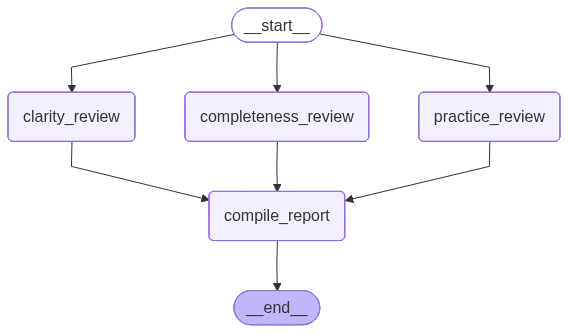

In [ ]:
parallel_builder = StateGraph(ReviewState)
parallel_builder.add_node("clarity_review", clarity_review)
parallel_builder.add_node("completeness_review", completeness_review)
parallel_builder.add_node("practice_review", practice_review)
parallel_builder.add_node("compile_report", compile_report)

parallel_builder.add_edge(START, "clarity_review")  # these three branches start from the same level
parallel_builder.add_edge(START, "completeness_review")
parallel_builder.add_edge(START, "practice_review")
parallel_builder.add_edge("clarity_review", "compile_report")  # fan-in happens here
parallel_builder.add_edge("completeness_review", "compile_report")
parallel_builder.add_edge("practice_review", "compile_report")
parallel_builder.add_edge("compile_report", END)

parallel_graph = parallel_builder.compile()
show_graph(parallel_graph)

In [ ]:
result = parallel_graph.invoke(
    {
        "question": "How does LangGraph help organize a retrieval pipeline?",
        "notes": [],
        "final_report": "",
    }
)
print(result["final_report"])


Parallel review summary:
- Clarity reviewer: define any technical term in 'How does LangGraph help organize a retrieval pipeline?'.
- Completeness reviewer: cover both the workflow logic and the data flow.
- Practice reviewer: add one runnable example for students to modify.


## 11.2 Map-Reduce with `Send`

Fixed fan-out is great when you already know how many branches you need. Map-reduce is what you use when the number of workers depends on the input itself.

The pattern here is:

1. split the input into parts
2. dynamically spawn one worker per part
3. collect all partial outputs through a reducer
4. synthesize them into a final result

In LangGraph, `Send` is the mechanism that creates those worker calls dynamically. Each `Send(...)` says: "run this node with this smaller piece of state."

Read the graph like this:

```text
START
  -> split_document
  -> summarize_section (one worker per paragraph)
  -> reduce_summaries
  -> END
```

So the map step is not just parallelism; it is **dynamic** parallelism. The graph does not know the number of workers until it reads the document.

References:

* Use the Graph API - Map-Reduce and the Send API: https://docs.langchain.com/oss/python/langgraph/use-graph-api
* Graph API overview - `Send`: https://docs.langchain.com/oss/python/langgraph/graph-api
* Workflows + agents - Orchestrator-worker: https://docs.langchain.com/oss/python/langgraph/workflows-agents


In [ ]:
from langgraph.types import Send


class MapReduceState(TypedDict):
    document: str
    sections: list[str]
    partial_summaries: Annotated[list[str], operator.add]  # collect outputs from all workers
    final_summary: str


class SectionState(TypedDict):
    section: str


def split_document(state: MapReduceState):
    sections = [part.strip() for part in state["document"].split("\n\n") if part.strip()]
    print("Number of Splits: ", len(sections))
    return {"sections": sections}


def map_sections(state: MapReduceState):
    return [Send("summarize_section", {"section": section}) for section in state["sections"]]


def summarize_section(state: SectionState):
    prompt = (
        "Summarize the following paragraph in one concise sentence.\n\n"
        f"Paragraph:\n{state['section']}"
    )
    response = llm.invoke(prompt)
    return {"partial_summaries": [response.content]}


def reduce_summaries(state: MapReduceState):
    joined = "\n".join(state["partial_summaries"])
    prompt = (
        "Combine the following partial summaries into one short overview.\n\n"
        f"Partial summaries:\n{joined}"
    )
    response = llm.invoke(prompt)
    return {"final_summary": response.content}


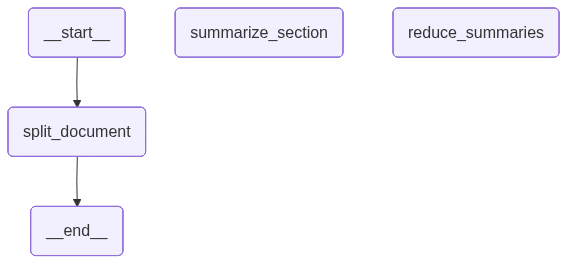

In [ ]:
map_reduce_builder = StateGraph(MapReduceState)
map_reduce_builder.add_node("split_document", split_document)
map_reduce_builder.add_node("summarize_section", summarize_section)
map_reduce_builder.add_node("reduce_summaries", reduce_summaries)

map_reduce_builder.add_edge(START, "split_document")
map_reduce_builder.add_conditional_edges("split_document", map_sections)  # one Send(...) per section
map_reduce_builder.add_edge("summarize_section", "reduce_summaries")  # fan-in after all workers finish
map_reduce_builder.add_edge("reduce_summaries", END)

map_reduce_graph = map_reduce_builder.compile()
show_graph(map_reduce_graph)


In [ ]:
toy_document = (
    "LangGraph makes workflow control explicit by turning each step into a node that reads from and writes to shared state.\n\n"
    "Because the transitions are explicit, it becomes easier to debug routing, memory, tool execution, and intermediate outputs.\n\n"
    "This is especially useful when we want to parallelize retrieval, save user preferences, or package parts of an application as reusable subgraphs."
)

result = map_reduce_graph.invoke(
    {
"document": toy_document,
"sections": [],
"partial_summaries": [],
"final_summary": "",
    }
)

print("Partial summaries:\n")
for summary in result["partial_summaries"]:
    print("-", summary)

print("\nFinal summary:\n")
print(result["final_summary"])

Number of Splits:  3
Partial summaries:

- LangGraph makes workflow control explicit by representing each step as a node that reads from and writes to a shared state.
- Explicit transitions simplify debugging of routing, memory, tool execution, and intermediate outputs.
- It enables parallel retrieval, preference storage, and the packaging of application components as reusable subgraphs.

Final summary:

LangGraph makes workflow control explicit by modeling each step as a node that reads from and writes to a shared state. This clear, node‑to‑node transition structure simplifies debugging of routing, memory handling, tool execution, and intermediate outputs. It also supports parallel retrieval, persistent preference storage, and the packaging of application components into reusable sub‑graphs.


# Section 12. Retrieval Workflow, Subgraphs, and RAG as a Tool

In the previous notebook, we used a tiny web-search graph just to make the data flow visible. Here we do something slightly more ambitious: build a hybrid retrieval workflow, inspect it on its own, and then expose it as a **tool inside a subgraph**.

That order matters. A subgraph is just a graph we understand well enough to package and reuse inside a bigger graph. **The change in this version is that the parent graph does not call the RAG pipeline directly. Instead, the RAG pipeline becomes a callable tool used by a specialized subgraph.**

References:

* Subgraphs: https://docs.langchain.com/oss/python/langgraph/use-subgraphs


In [ ]:
from pathlib import Path

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf_path = Path("nke-10k-2023.pdf")

loader = PyPDFLoader(str(pdf_path))
nike_docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True,
)
rag_docs = text_splitter.split_documents(nike_docs)

for i, doc in enumerate(rag_docs):
    doc.metadata["chunk_id"] = f"rag_chunk_{i}"

rag_vector_store = InMemoryVectorStore(embeddings)
rag_vector_store.add_documents(documents=rag_docs)

dense_retriever = rag_vector_store.as_retriever(search_kwargs={"k": 3})
sparse_retriever = BM25Retriever.from_documents(rag_docs)
sparse_retriever.k = 3

print(f"Loaded {len(nike_docs)} raw documents and {len(rag_docs)} chunks.")


Loaded 107 raw documents and 516 chunks.


### Retrieval workflow

We will first build the retrieval workflow as a normal graph.

Its job is to do four things:

1. expand the user query
2. run dense retrieval
3. run sparse retrieval
4. fuse the ranked results


In [ ]:
from collections import defaultdict

from langchain_core.prompts import ChatPromptTemplate

def preview_docs(docs, max_chars=200):
    for i, doc in enumerate(docs, start=1):
        chunk_id = doc.metadata.get("chunk_id", f"doc_{i}")
        snippet = doc.page_content[:max_chars].replace("\n", " ")
        print(f"{i}. {chunk_id}")
        print(snippet)
        print("-" * 80)

query_expansion_prompt = ChatPromptTemplate.from_template(
    """You are helping a retrieval system.
Generate {n} short alternative search queries for the question below.
Rules:
- preserve the original meaning
- vary wording and keywords
- return one query per line
- do not number the lines

Question: {question}
"""
)

def expand_queries(question, n=2):
    prompt = query_expansion_prompt.invoke({"question": question, "n": n})
    response = llm.invoke(prompt)
    lines = [line.strip().strip("-0123456789. ") for line in response.content.splitlines() if line.strip()]
    deduped = []
    for line in lines:
        if line and line not in deduped:
            deduped.append(line)
    return [question] + deduped[:n]

def reciprocal_rank_fusion(rankings, c=60):
    scores = defaultdict(float)
    docs_by_id = {}
    for ranking in rankings:
        for rank, doc in enumerate(ranking, start=1):
            doc_id = doc.metadata.get("chunk_id", f"doc_{rank}")
            scores[doc_id] += 1 / (c + rank)
            docs_by_id[doc_id] = doc
    ranked_ids = sorted(scores, key=scores.get, reverse=True)
    return [docs_by_id[doc_id] for doc_id in ranked_ids]

class RetrievalState(TypedDict):
    question: str
    expanded_queries: list[str]
    dense_docs: list[Document]
    sparse_docs: list[Document]
    fused_docs: list[Document]

def expand_query_node(state: RetrievalState):
    return {"expanded_queries": expand_queries(state["question"], n=2)}

def dense_retrieve_node(state: RetrievalState):
    docs = []
    seen = set()
    for query_variant in state["expanded_queries"]:
        for doc in dense_retriever.invoke(query_variant):
            doc_id = doc.metadata.get("chunk_id")
            if doc_id not in seen:
                seen.add(doc_id)
                docs.append(doc)
    return {"dense_docs": docs}

def sparse_retrieve_node(state: RetrievalState):
    docs = []
    seen = set()
    for query_variant in state["expanded_queries"]:
        for doc in sparse_retriever.invoke(query_variant):
            doc_id = doc.metadata.get("chunk_id")
            if doc_id not in seen:
                seen.add(doc_id)
                docs.append(doc)
    return {"sparse_docs": docs}


def fuse_node(state: RetrievalState):
    fused = reciprocal_rank_fusion([state["dense_docs"], state["sparse_docs"]])[:4]
    return {"fused_docs": fused}


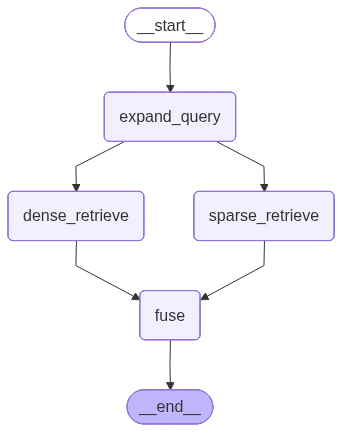

In [ ]:
retrieval_builder = StateGraph(RetrievalState)
retrieval_builder.add_node("expand_query", expand_query_node)
retrieval_builder.add_node("dense_retrieve", dense_retrieve_node)
retrieval_builder.add_node("sparse_retrieve", sparse_retrieve_node)
retrieval_builder.add_node("fuse", fuse_node)

retrieval_builder.add_edge(START, "expand_query")
retrieval_builder.add_edge("expand_query", "dense_retrieve")
retrieval_builder.add_edge("expand_query", "sparse_retrieve")  # both retrieval branches start after query expansion
retrieval_builder.add_edge("dense_retrieve", "fuse")
retrieval_builder.add_edge("sparse_retrieve", "fuse")  # fan-in: fuse waits for both branches
retrieval_builder.add_edge("fuse", END)

retrieval_graph = retrieval_builder.compile()
show_graph(retrieval_graph)


In [ ]:
retrieval_result = retrieval_graph.invoke(
    {
        "question": "How were Nike's margins impacted in 2023?",
        "expanded_queries": [],
        "dense_docs": [],
        "sparse_docs": [],
        "fused_docs": [],
    }
)

print("Expanded queries:")
for item in retrieval_result["expanded_queries"]:
    print("-", item)

print("\nDense retrieval:")
preview_docs(retrieval_result["dense_docs"], max_chars=140)

print("Sparse retrieval:")
preview_docs(retrieval_result["sparse_docs"], max_chars=140)

print("Fused results:")
preview_docs(retrieval_result["fused_docs"], max_chars=140)


Expanded queries:
- How were Nike's margins impacted in 2023?
- Nike 2023 profit margin impact
- Nike margins change in

Dense retrieval:
1. rag_chunk_222
Table of Contents GROSS MARGIN FISCAL 2023 COMPARED TO FISCAL 2022 For fiscal 2023, our consolidated gross profit increased 4% to $22,292 mi
--------------------------------------------------------------------------------
2. rag_chunk_250
• Gross margin contraction of approximately 190 basis points primarily due to higher product costs, reflecting product mix and higher input 
--------------------------------------------------------------------------------
3. rag_chunk_209
of Income. Total NIKE, Inc. EBIT for fiscal 2023 and fiscal 2022 is as follows: YEAR ENDED MAY 31, (Dollars in millions) 2023 2022 Net incom
--------------------------------------------------------------------------------
4. rag_chunk_201
Enterprise Resource Planning Platform, data and analytics, demand sensing, insight gathering, and other areas to create an end-t

### Converting it to a RAG tool subgraph

Now that the retrieval workflow makes sense on its own, we can wrap it as a tool.

We could just call `retrieval_graph.invoke` inside a tool, but in this example, we will explore a rag_tool_subgraph, that does just that, inside a parent graph, so we can explore subgraphs on LangGraph.

```text
parent graph
  -> rag_tool_subgraph
        -> assistant decides to call nike_rag_tool
        -> ToolNode executes the RAG tool
        -> assistant converts the tool result into a message
  -> final_editor
```

**Why this design?** It makes RAG one capability of a specialized subgraph. Later, the same subgraph could choose between local RAG, web search, SQL, or another retrieval tool without changing the parent graph.

References:

* Subgraphs: https://docs.langchain.com/oss/python/langgraph/use-subgraphs


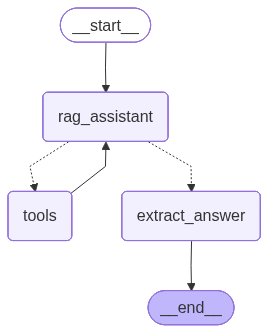

In [ ]:
from typing import Any

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant for question answering. Use only the retrieved context. If the answer is not present in the context, say that you do not know.",
        ),
        (
            "human",
            "Question: {question}\n\nContext:\n{context}",
        ),
    ]
)


@tool
def nike_rag_tool(question: str) -> str:
    """Answer a question using the local Nike RAG corpus loaded in this notebook."""
    retrieval_result = retrieval_graph.invoke(
        {
            "question": question,
            "expanded_queries": [],
            "dense_docs": [],
            "sparse_docs": [],
            "fused_docs": [],
        }
    )

    context = "\n\n".join(doc.page_content for doc in retrieval_result["fused_docs"])
    sources = sorted({doc.metadata.get("source", "unknown") for doc in retrieval_result["fused_docs"]})

    prompt = rag_prompt.invoke({"question": question, "context": context})
    response = llm.invoke(prompt)

    return (
        response.content
        + "\n\nRetrieved sources: "
        + ", ".join(sources)
    )

# Other tools could be included, like web search or SQL


rag_tools = [nike_rag_tool]
rag_tool_node = ToolNode(rag_tools)
rag_tool_llm = llm.bind_tools(rag_tools)


class RAGToolSubgraphState(TypedDict):
    question: str
    messages: Annotated[list[AnyMessage], add_messages]
    rag_answer: str


def rag_assistant_node(state: RAGToolSubgraphState):
    user_messages = state.get("messages", [])
    if not user_messages:
        user_messages = [HumanMessage(content=state["question"])]

    system = SystemMessage(
        content=(
            "You are a RAG specialist subgraph. "
            "For any question about the Nike corpus, call nike_rag_tool first. "
            "After the tool returns, answer in 3-5 sentences and cite the retrieved source names."
        )
    )
    response = rag_tool_llm.invoke([system] + user_messages)
    return {"messages": [response]}


def route_after_rag_assistant(state: RAGToolSubgraphState):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "extract_answer"


def extract_rag_answer_node(state: RAGToolSubgraphState):
    return {"rag_answer": state["messages"][-1].content}


rag_subgraph_builder = StateGraph(RAGToolSubgraphState)
rag_subgraph_builder.add_node("rag_assistant", rag_assistant_node)
rag_subgraph_builder.add_node("tools", rag_tool_node)
rag_subgraph_builder.add_node("extract_answer", extract_rag_answer_node)

rag_subgraph_builder.add_edge(START, "rag_assistant")
rag_subgraph_builder.add_conditional_edges(
    "rag_assistant",
    route_after_rag_assistant,
    {
        "tools": "tools",
        "extract_answer": "extract_answer",
    },
)
rag_subgraph_builder.add_edge("tools", "rag_assistant")
rag_subgraph_builder.add_edge("extract_answer", END)

rag_tool_subgraph = rag_subgraph_builder.compile()
show_graph(rag_tool_subgraph)


Now, let's build the main graph.

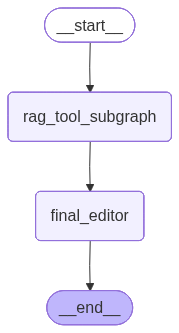

In [ ]:
class ParentRAGState(TypedDict):
    question: str
    messages: Annotated[list[AnyMessage], add_messages]
    rag_answer: str
    final_answer: str


def final_editor_node(state: ParentRAGState):
    prompt = ChatPromptTemplate.from_template(
        """Rewrite the answer below for a student who is learning about a topic.
Keep the factual content, but make the structure clearer.

Question:
{question}

RAG answer:
{rag_answer}
"""
    )
    response = llm.invoke(prompt.invoke({"question": state["question"], "rag_answer": state["rag_answer"]}))
    return {"final_answer": response.content}


parent_rag_builder = StateGraph(ParentRAGState)
parent_rag_builder.add_node("rag_tool_subgraph", rag_tool_subgraph)
parent_rag_builder.add_node("final_editor", final_editor_node)

parent_rag_builder.add_edge(START, "rag_tool_subgraph")
parent_rag_builder.add_edge("rag_tool_subgraph", "final_editor")
parent_rag_builder.add_edge("final_editor", END)

graph_rag = parent_rag_builder.compile()
show_graph(graph_rag)

In [ ]:
question = "How were Nike's margins impacted in 2023?"

result = graph_rag.invoke(
    {
        "question": question,
        "messages": [],
        "rag_answer": "",
        "final_answer": "",
    }
)

print("RAG subgraph answer:\n")
print(result["rag_answer"])

print('='*50)

print("\nFinal edited answer:\n")
print(result["final_answer"])


RAG subgraph answer:

Nike’s margins were squeezed in fiscal 2023, with gross margin falling about 250 basis points—from 46.0 % in FY 2022 to **43.5 % in FY 2023**. The decline stemmed mainly from higher NIKE‑Brand product costs (inputs, freight, logistics), an adverse product mix, lower NIKE Direct margins due to extra promotions, and unfavorable foreign‑currency movements. These pressures outweighed gains from higher full‑price ASPs, resulting in a net gross‑margin contraction of roughly 190–250 basis points for the year【nke-10k-2023.pdf】.

Final edited answer:

**What happened to Nike’s margins in fiscal 2023?**

| Metric | FY 2022 | FY 2023 | Change |
|--------|---------|---------|--------|
| Gross‑margin percentage | 46.0 % | 43.5 % | **‑2.5 percentage points** (≈ 250 basis points) |

### Why did the margin fall?

1. **Higher product‑costs for the NIKE brand**  
   * More expensive raw materials, freight and logistics.  

2. **Unfavourable product mix**  
   * A larger share of lo

# Section 13. DeepAgents

A normal tool-calling agent is often enough for short tasks. A **DeepAgent** is useful when the task starts to look more like a mini-project: planning, using files, delegating work, keeping context organized, and iterating over results.

A LangChain `deepagents` is described as a standalone library built on LangChain building blocks and using the LangGraph runtime it is capabile of complex taks such as planning, filesystem tools, subagents, and context management.

Here we use a small coding task as the example:

```text
buggy code
  -> generate or propose tests
  -> run tests
  -> revise code
  -> evaluate result
```

Official references:

* DeepAgents overview: https://docs.langchain.com/oss/python/deepagents/overview
* DeepAgents quickstart: https://docs.langchain.com/oss/python/deepagents/quickstart
* DeepAgents customization: https://docs.langchain.com/oss/python/deepagents/customization
* DeepAgents repository: https://github.com/langchain-ai/deepagents


In [12]:
import subprocess
import sys
import tempfile
import textwrap
from pathlib import Path
from langchain_core.tools import tool

from deepagents import create_deep_agent


BUGGY_CODE = """
def add_positive_numbers(a: int, b: int) -> int:
    \"\"\"Return the sum of two positive integers.\"\"\"
    if a < 0 or b < 0:
        raise ValueError("Only positive numbers are allowed")
    return a - b
"""


@tool
def run_python_tests(code: str, tests: str) -> str:
    """Run pytest against a Python code string and a pytest test string. Returns stdout and stderr."""
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp = Path(tmpdir)
        (tmp / "solution.py").write_text(code, encoding="utf-8")
        (tmp / "test_solution.py").write_text(tests, encoding="utf-8")

        try:
            completed = subprocess.run(
                [sys.executable, "-m", "pytest", "-q"],
                cwd=tmp,
                capture_output=True,
                text=True,
                timeout=10,
            )
            return (
                f"exit_code={completed.returncode}\n\n"
                f"STDOUT:\n{completed.stdout}\n\n"
                f"STDERR:\n{completed.stderr}"
            )
        except subprocess.TimeoutExpired:
            return "The test run timed out."


coding_deep_agent = create_deep_agent(
    model=llm,
    tools=[run_python_tests],
    system_prompt=(
        "You are a careful Python coding assistant. "
        "For this classroom demo, generate pytest tests, call run_python_tests, "
        "revise the code if needed, and then explain the final fix. "
        "Do not use network access or system commands."
    ),
)

deep_agent_result = coding_deep_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Fix this function. Keep the API the same. "
                    "First create tests, run them, then provide the corrected code.\n\n"
                    f"```python\n{BUGGY_CODE}\n```"
                ),
            }
        ]
    }
)

print(deep_agent_result["messages"][-1].content)


Implemented proper addition logic:

- Updated `add_positive_numbers` to return `a + b` instead of `a - b`.
- Added comprehensive pytest suite:
  - Tests correct sums for various positive inputs.
  - Verifies `ValueError` is raised for any negative argument.

All tests now pass (`2 passed`). The function’s API remains unchanged.


In [ ]:
for i, msg in enumerate(deep_agent_result["messages"]):
    print("\n" + "=" * 40)
    print(f"Message {i}: {type(msg).__name__}")
    msg.pretty_print()


Message 0: HumanMessage
================================ Human Message =================================

Fix this function. Keep the API the same. First create tests, run them, then provide the corrected code.

```python

def add_positive_numbers(a: int, b: int) -> int:
    """Return the sum of two positive integers."""
    if a < 0 or b < 0:
        raise ValueError("Only positive numbers are allowed")
    return a - b

```

Message 1: AIMessage
================================== Ai Message ==================================
Tool Calls:
  write_file (chatcmpl-tool-a6d316dabf0a1e38)
 Call ID: chatcmpl-tool-a6d316dabf0a1e38
  Args:
    file_path: /add.py
    content: def add_positive_numbers(a: int, b: int) -> int:
    """Return the sum of two positive integers."""
    if a < 0 or b < 0:
        raise ValueError("Only positive numbers are allowed")
    return a - b

Message 2: ToolMessage
================================= Tool Message =================================
Name: write_file

## (Extra) The same idea as an explicit LangGraph coding loop

The DeepAgent version is convenient because many project-oriented behaviors are already packaged. For teaching, it is also useful to show the lower-level graph explicitly.

The graph below keeps the control flow visible:

```text
generate_code -> generate_tests -> run_tests -> evaluate
                     ^                 |
                     |                 v
                 revise_code <--- if tests fail
```

This is not a secure sandbox. **Use this only with small trusted classroom snippets**, because executing model-generated code can be dangerous.


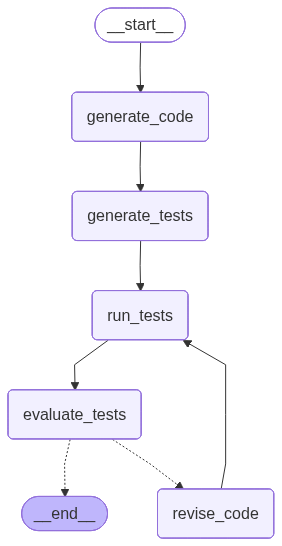

In [ ]:
import re

def extract_python_code(text: str) -> str:
    """Extract a Python code block if one exists; otherwise return the raw text."""
    match = re.search(r"```python\s*(.*?)```", text, flags=re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()


class CodingLoopState(TypedDict):
    task: str
    code: str
    tests: str
    test_output: str
    review: str
    passed: bool
    attempts: int


def generate_code_node(state: CodingLoopState):
    prompt = ChatPromptTemplate.from_template(
        """Write a small Python solution for the task below.
Return only Python code, with no markdown.

Task:
{task}
"""
    )
    response = llm.invoke(prompt.invoke({"task": state["task"]}))
    return {"code": extract_python_code(response.content), "attempts": 1}


def generate_tests_node(state: CodingLoopState):
    prompt = ChatPromptTemplate.from_template(
        """Write pytest tests for solution.py.
Assume the implementation will be imported from solution.py.
Return only Python code, with no markdown.

Task:
{task}

Current solution:
{code}
"""
    )
    response = llm.invoke(prompt.invoke({"task": state["task"], "code": state["code"]}))
    return {"tests": extract_python_code(response.content)}


def run_tests_node(state: CodingLoopState):
    output = run_python_tests.invoke({"code": state["code"], "tests": state["tests"]})
    return {"test_output": output}


def evaluate_tests_node(state: CodingLoopState):
    passed = "exit_code=0" in state["test_output"]
    if passed:
        review = "Tests passed. The code is ready for classroom inspection."
    else:
        review = "Tests failed. Revise the implementation using the test output."
    return {"passed": passed, "review": review}


def revise_code_node(state: CodingLoopState):
    prompt = ChatPromptTemplate.from_template(
        """The tests failed. Revise the Python code.

Task:
{task}

Current code:
{code}

Tests:
{tests}

Test output:
{test_output}

Return only corrected Python code, with no markdown.
"""
    )
    response = llm.invoke(
        prompt.invoke(
            {
                "task": state["task"],
                "code": state["code"],
                "tests": state["tests"],
                "test_output": state["test_output"],
            }
        )
    )
    return {
        "code": extract_python_code(response.content),
        "attempts": state["attempts"] + 1,
    }


def route_after_evaluation(state: CodingLoopState):
    if state["passed"] or state["attempts"] >= 3:
        return END
    return "revise_code"


coding_builder = StateGraph(CodingLoopState)
coding_builder.add_node("generate_code", generate_code_node)
coding_builder.add_node("generate_tests", generate_tests_node)
coding_builder.add_node("run_tests", run_tests_node)
coding_builder.add_node("evaluate_tests", evaluate_tests_node)
coding_builder.add_node("revise_code", revise_code_node)

coding_builder.add_edge(START, "generate_code")
coding_builder.add_edge("generate_code", "generate_tests")
coding_builder.add_edge("generate_tests", "run_tests")
coding_builder.add_edge("run_tests", "evaluate_tests")
coding_builder.add_conditional_edges(
    "evaluate_tests",
    route_after_evaluation,
    {
        "revise_code": "revise_code",
        END: END,
    },
)
coding_builder.add_edge("revise_code", "run_tests")

coding_graph = coding_builder.compile()
show_graph(coding_graph)


In [ ]:
coding_result = coding_graph.invoke(
    {
        "task": (
            "Create a function add_positive_numbers(a: int, b: int) -> int. "
            "It should return a + b and raise ValueError if either input is negative."
        ),
        "code": "",
        "tests": "",
        "test_output": "",
        "review": "",
        "passed": False,
        "attempts": 0,
    }
)

print("Passed:", coding_result["passed"])
print("Attempts:", coding_result["attempts"])

print("\nFinal code:\n")
print(coding_result["code"])

print("\nTests:\n")
print(coding_result["tests"])

print("\nTest output:\n")
print(coding_result["test_output"])

print("\nReview:\n")
print(coding_result["review"])


Passed: True
Attempts: 1

Final code:

def add_positive_numbers(a: int, b: int) -> int:
    """
    Return the sum of a and b if both are non‑negative.
    Raises:
        ValueError: If either a or b is negative.
    """
    if a < 0 or b < 0:
        raise ValueError("Both numbers must be non‑negative")
    return a + b

Tests:

import pytest
from solution import add_positive_numbers

@pytest.mark.parametrize(
    "a, b, expected",
    [
        (1, 2, 3),
        (0, 0, 0),
        (0, 5, 5),
        (123456, 654321, 777777),
        (10, 0, 10),
    ],
)
def test_add_positive_numbers_valid(a, b, expected):
    """Test that add_positive_numbers returns the correct sum for non‑negative inputs."""
    assert add_positive_numbers(a, b) == expected


@pytest.mark.parametrize(
    "a, b",
    [
        (-1, 0),
        (0, -1),
        (-5, -10),
        (-100, 50),
        (25, -30),
    ],
)
def test_add_positive_numbers_negative_input_raises(a, b):
    """Test that a ValueError is rai

# Section 14. DeepAgents with `SKILL.md`

The previous section gave the agent a callable tool, `run_python_tests`. That is useful when an action can be represented as a small Python function. A **skill** solves a different problem: it packages a reusable workflow as files that the agent can discover and read only when needed.

A Deep Agent skill is a folder. The required file is `SKILL.md`; it contains YAML frontmatter such as `name` and `description`, followed by Markdown instructions. The folder can also include scripts, templates, docs, or examples. DeepAgents uses a **progressive disclosure** pattern: the agent sees skill descriptions first, and it reads the full `SKILL.md` only when the task appears to match. This lets us keep the main system prompt small while still giving the agent rich procedures for specialized work.

Use a skill when the capability is more like a playbook than a single function:

1. coding conventions for one repo or team
2. a test-first repair workflow
3. a documentation lookup procedure
4. a report or PRD template
5. a script bundle the agent may use through the filesystem

Use a normal tool when the agent needs a precise callable action, such as `run_python_tests(code, tests)` or `nike_rag_tool(question)`. In practice, strong agents often use both: tools provide reliable actions; skills explain when and how to combine those actions.

References:

* DeepAgents skills documentation: https://docs.langchain.com/oss/python/deepagents/skills
* LangChain blog, Using skills with Deep Agents: https://www.langchain.com/blog/using-skills-with-deep-agents

In [7]:
from deepagents import create_deep_agent
from deepagents.backends.utils import create_file_data
from langgraph.checkpoint.memory import MemorySaver


pytest_fixer_skill_md = """
---
name: pytest-fixer
description: Use this skill when asked to fix a small Python function by writing pytest tests, running them, interpreting failures, and revising the code.
---

# pytest-fixer

## Goal

Fix a small Python function using a test-first loop.

## Workflow

1. Read the user's task and the provided code.
2. Write a minimal pytest suite that checks normal behavior and edge cases.
3. Run `run_python_tests` on the original code and the tests.
4. Use any failing output to revise the implementation.
5. Run `run_python_tests` again.
6. Return:
   - corrected code
   - tests used
   - final test output
   - a short explanation of the bug and fix

## Constraints

- Keep the original public API unless the user asks otherwise.
- Do not use network access.
- Do not use shell commands directly; use the provided `run_python_tests` tool.
""".strip()

# With the default StateBackend, skill files can be seeded into the agent state.
# Virtual paths should start with `/`.
skills_files = {
    "/skills/pytest-fixer/SKILL.md": create_file_data(pytest_fixer_skill_md)
}

print(pytest_fixer_skill_md[:500] + "\n...")


---
name: pytest-fixer
description: Use this skill when asked to fix a small Python function by writing pytest tests, running them, interpreting failures, and revising the code.
---

# pytest-fixer

## Goal

Fix a small Python function using a test-first loop.

## Workflow

1. Read the user's task and the provided code.
2. Write a minimal pytest suite that checks normal behavior and edge cases.
3. Run `run_python_tests` on the original code and the tests.
4. Use any failing output to revise the 
...


Just to make sure the SKILL.md was created.

In [9]:
import os

# Create the directory if it doesn't exist
os.makedirs("/skills/pytest-fixer", exist_ok=True)

# Write the content to the skill file
with open("/skills/pytest-fixer/SKILL.md", "w", encoding="utf-8") as f:
    f.write(pytest_fixer_skill_md)

!ls -F /skills

pytest-fixer/


In [13]:
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend


skills_agent = create_deep_agent(
    model=llm,
    tools=[run_python_tests],
    backend=FilesystemBackend(root_dir="."),
    skills=["/skills/"],  # contains pytest-fixer/SKILL.md
    system_prompt=(
        "Use the pytest-fixer skill when the user asks to fix Python code with tests. "
        "Use run_python_tests to execute pytest. "
        "Keep the final answer concise."
    ),
)

skills_result = skills_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Fix this function. Keep the API the same. "
                    "Create tests, run them, and revise the code if needed.\n\n"
                    f"```python\n{BUGGY_CODE}\n```"
                ),
            }
        ]
    }
)

print(skills_result["messages"][-1].content)

/tmp/ipykernel_4867/1356899579.py:8: LangChainDeprecationWarning: `FilesystemBackend` `virtual_mode` default will change in deepagents==0.6.0; please specify `virtual_mode` explicitly. Note: `virtual_mode` is for virtual path semantics (e.g., `CompositeBackend` routing) and optional path-based guardrails; it does not provide sandboxing or process isolation. Security note: leaving `virtual_mode=False` allows absolute paths and `'..'` to bypass `root_dir`. Consult the API reference for details.
  backend=FilesystemBackend(root_dir="."),


**Corrected code**

```python
def add_positive_numbers(a: int, b: int) -> int:
    """Return the sum of two positive integers."""
    if a < 0 or b < 0:
        raise ValueError("Only positive numbers are allowed")
    return a + b
```

**Tests**

```python
import pytest
from solution import add_positive_numbers

def test_add_positive():
    assert add_positive_numbers(2, 3) == 5
    assert add_positive_numbers(0, 5) == 5
    assert add_positive_numbers(10, 0) == 10

def test_negative_raises():
    with pytest.raises(ValueError):
        add_positive_numbers(-1, 5)
    with pytest.raises(ValueError):
        add_positive_numbers(5, -2)
```

**Test result**

```
..                                                                       [100%]
2 passed in 0.01s
```

**Explanation**

The original implementation returned `a - b`, which produced incorrect results (e.g., `2 - 3 = -1`). The fix changes the return statement to `a + b`, correctly summing the two positive integers while preserving

In [14]:
for i, msg in enumerate(skills_result["messages"]):
    print("\n" + "=" * 40)
    print(f"Message {i}: {type(msg).__name__}")
    msg.pretty_print()


Message 0: HumanMessage
================================ Human Message =================================

Fix this function. Keep the API the same. Create tests, run them, and revise the code if needed.

```python

def add_positive_numbers(a: int, b: int) -> int:
    """Return the sum of two positive integers."""
    if a < 0 or b < 0:
        raise ValueError("Only positive numbers are allowed")
    return a - b

```

Message 1: AIMessage
================================== Ai Message ==================================
Tool Calls:
  read_file (chatcmpl-tool-8c8ffd1a0f4f6a8b)
 Call ID: chatcmpl-tool-8c8ffd1a0f4f6a8b
  Args:
    file_path: /skills/pytest-fixer/SKILL.md
    limit: 1000

Message 2: ToolMessage
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: pytest-fixer
     3	description: Use this skill when asked to fix a small Python function by writing pytest tests, running them, interpreting failures, and revis

# Section 15. Ralph loop and continuous agents

A Ralph loop uses the same idea of "work -> check -> retry", but the loop lives outside the agent.

What occurred in the Ralph-style flow:

1. Ralph reads the current PRD, task list, repo state, and progress.
2. It starts a fresh agent run for the next small slice.
3. The agent changes files and writes progress back to the project.
4. Ralph runs checks: tests, lint, typecheck, browser checks, or acceptance criteria.
5. If the slice passes, it is marked done. If not, Ralph starts another fresh iteration.

The continuity is not inside one long chat. It comes from durable state: files, commits, logs, tests, and task status.

Compared with a LangGraph loop:

| Pattern | Where the loop lives | Memory | Best for |
|---|---|---|---|
| LangGraph loop | Inside a graph execution | graph state and checkpoints | controlled workflows, bounded task graphs, review and retry loops |
| Ralph loop | Outside the agent, often as a shell or process loop | filesystem, git history, progress logs, task JSON | long-running coding tasks, overnight work, repeated fresh-context attempts |

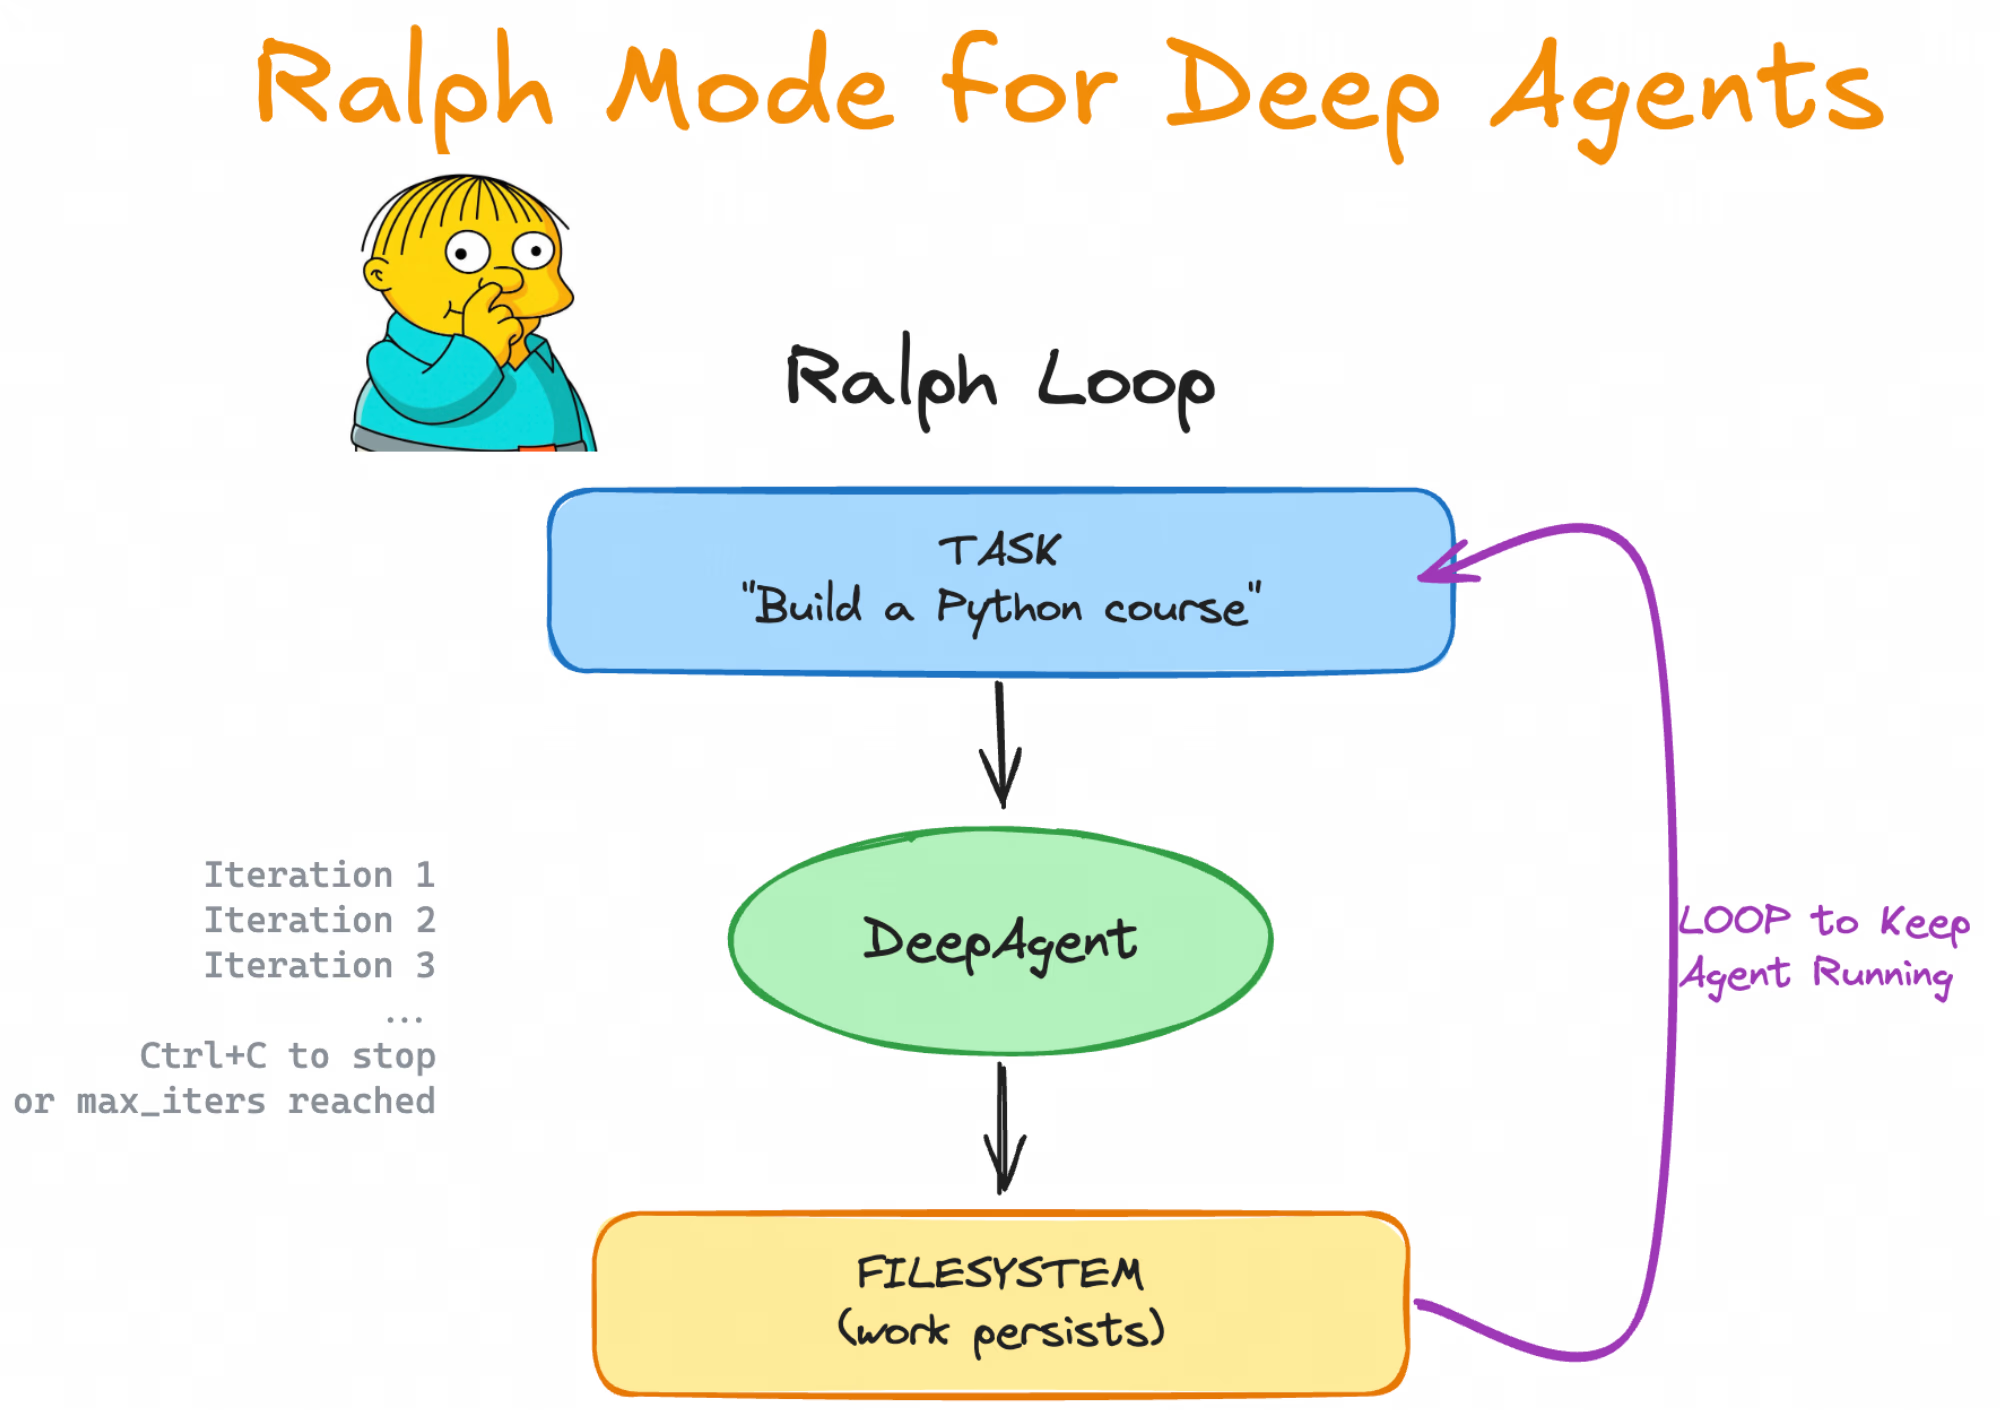